# Data Visualization Progression: From Basic to Exhibitive
## Matplotlib Edition (No Plotly Required)

## Learning Objectives

In this notebook, you'll learn how to transform basic plots into professional, publication-ready visualizations using **Matplotlib only**.

We'll explore:
1. **Basic Plots** - Quick exploration with minimal code
2. **Explanatory Plots** - Clear communication with context and styling
3. **Exhibitive Plots** - Professional, publication-ready visualizations

---

## Dataset: HR Analytics

We'll use employee data to explore patterns in attrition (employees leaving the company).

In [1]:
# Import necessary libraries (only standard packages)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('default')
sns.set_palette("husl")

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


In [2]:
# Load the HR Analytics dataset
df = pd.read_csv('data/HR_Analytics.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (1480, 38)

First few rows:


,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


In [3]:
# Quick data exploration
print("Key Statistics:")
print(f"Total Employees: {len(df)}")
print(f"Attrition Rate: {(df['Attrition'] == 'Yes').sum() / len(df) * 100:.1f}%")
print(f"\nDepartments: {df['Department'].unique()}")
print(f"\nAge Range: {df['Age'].min()} - {df['Age'].max()} years")
print(f"Income Range: ${df['MonthlyIncome'].min()} - ${df['MonthlyIncome'].max()}")

Key Statistics:
Total Employees: 1480
Attrition Rate: 16.1%

Departments: ['Research & Development' 'Sales' 'Human Resources']

Age Range: 18 - 60 years
Income Range: $1009 - $19999


---

# Matplotlib Progression

## Visualization Goal
**How does monthly income relate to attrition across different departments?**

## Level 1: Basic Plot

### What We're Doing
Creating a simple scatter plot with **minimal code**.

### The Problem
While functional, this plot lacks context:
- No axis labels
- No title
- Can't distinguish attrition status

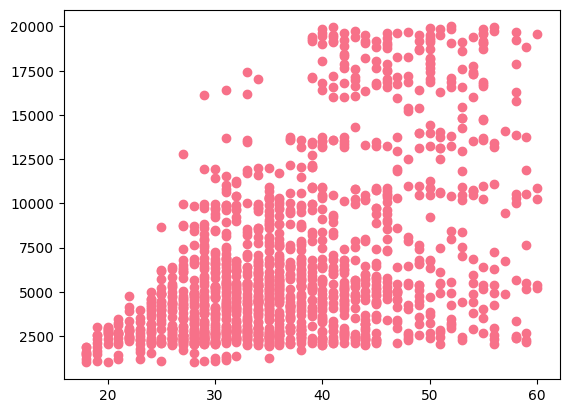

In [4]:
# BASIC PLOT - Minimal code, default settings
plt.figure()
plt.scatter(df['Age'], df['MonthlyIncome'])
plt.show()

### What Just Happened?

We created a scatter plot with just 3 lines:
1. `plt.figure()` - Creates canvas
2. `plt.scatter()` - Plots points
3. `plt.show()` - Displays plot

**Problem**: We can't tell which employees left!

---

## Level 2: Explanatory Plot

### What We're Adding
- Clear titles and labels
- Color coding for attrition
- Legend
- Larger size
- Grid for readability

### Why These Changes Matter
Every element reduces cognitive load - viewers don't have to guess.

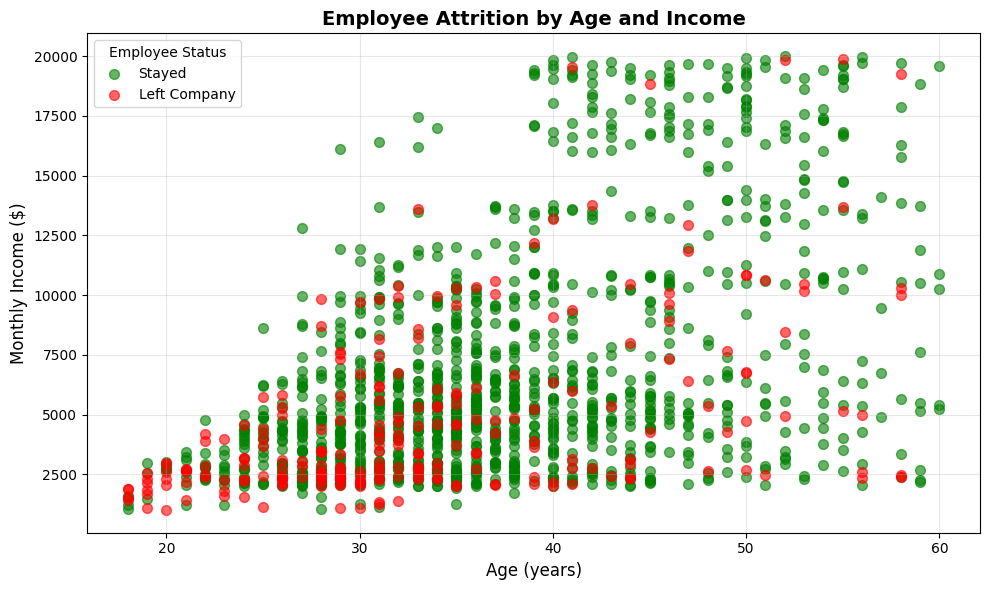

In [5]:
# EXPLANATORY PLOT - Added context and clarity

plt.figure(figsize=(10, 6))

# Plot each attrition group separately
for attrition_status in ['No', 'Yes']:
    mask = df['Attrition'] == attrition_status
    color = 'green' if attrition_status == 'No' else 'red'
    label = 'Stayed' if attrition_status == 'No' else 'Left Company'
    
    plt.scatter(df[mask]['Age'], 
                df[mask]['MonthlyIncome'],
                c=color,
                label=label,
                alpha=0.6,
                s=50)

plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Monthly Income ($)', fontsize=12)
plt.title('Employee Attrition by Age and Income', fontsize=14, fontweight='bold')
plt.legend(title='Employee Status', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What Changed?

1. **`figsize=(10, 6)`** - Larger canvas
2. **Loop through groups** - Separate colors
3. **`alpha=0.6`** - Transparency shows overlaps
4. **Labels with `fontsize`** - Readable
5. **Grid** - Helps estimate values

**Key Insight**: Younger, lower-paid employees show higher attrition!

---

## Level 3: Exhibitive Plot

### What We're Adding
- Professional color scheme
- Statistical trend lines
- Department subplots
- Annotations with metrics
- Polished styling

### Design Principle
The plot should stand alone - no explanation needed.

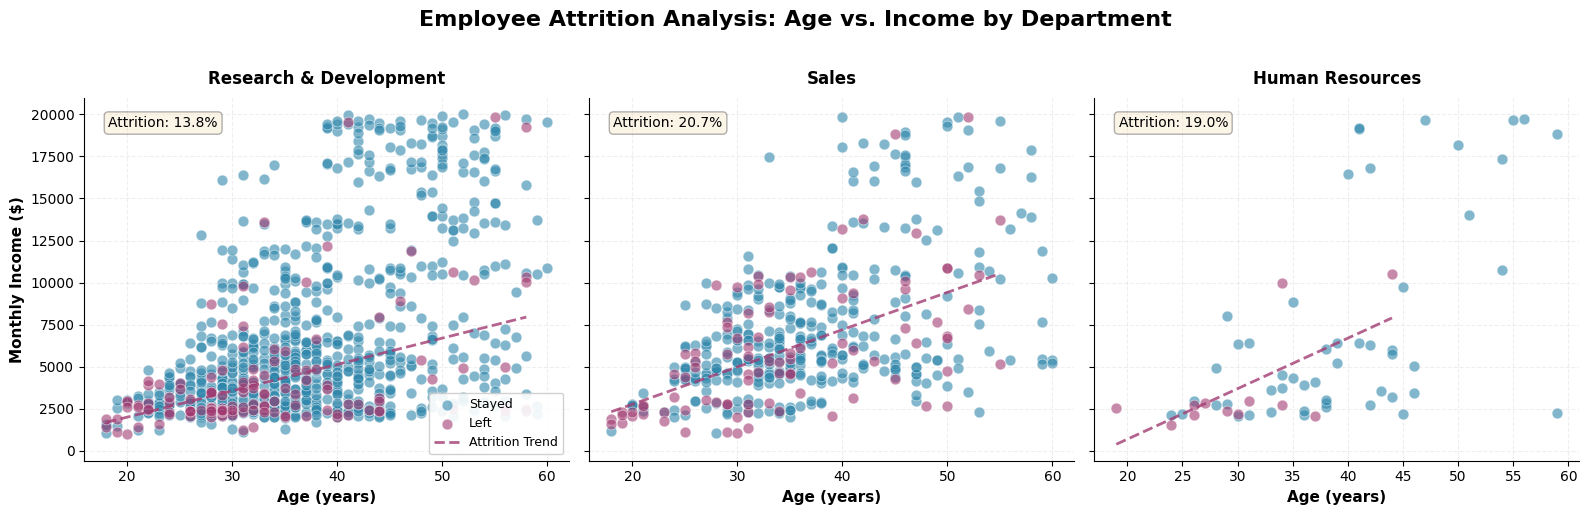

In [6]:
# EXHIBITIVE PLOT - Publication-ready

# Professional colors (colorblind-friendly)
colors = {'No': '#2E86AB', 'Yes': '#A23B72'}

departments = df['Department'].unique()

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('Employee Attrition Analysis: Age vs. Income by Department', 
             fontsize=16, fontweight='bold', y=1.02)

for idx, dept in enumerate(departments):
    ax = axes[idx]
    dept_data = df[df['Department'] == dept]
    
    # Plot each attrition group
    for attrition_status in ['No', 'Yes']:
        mask = dept_data['Attrition'] == attrition_status
        data = dept_data[mask]
        label = 'Stayed' if attrition_status == 'No' else 'Left'
        
        ax.scatter(data['Age'], 
                   data['MonthlyIncome'],
                   c=colors[attrition_status],
                   label=label,
                   alpha=0.6,
                   s=60,
                   edgecolors='white',
                   linewidth=0.5)
    
    # Add trend line
    left_data = dept_data[dept_data['Attrition'] == 'Yes']
    if len(left_data) > 1:
        z = np.polyfit(left_data['Age'], left_data['MonthlyIncome'], 1)
        p = np.poly1d(z)
        ages_sorted = np.sort(left_data['Age'].values)
        ax.plot(ages_sorted, p(ages_sorted),
                "--", color=colors['Yes'], alpha=0.8, linewidth=2,
                label='Attrition Trend')
    
    # Styling
    ax.set_xlabel('Age (years)', fontsize=11, fontweight='bold')
    if idx == 0:
        ax.set_ylabel('Monthly Income ($)', fontsize=11, fontweight='bold')
    
    ax.set_title(dept, fontsize=12, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add attrition rate
    attrition_rate = (dept_data['Attrition'] == 'Yes').sum() / len(dept_data) * 100
    ax.text(0.05, 0.95, f'Attrition: {attrition_rate:.1f}%',
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    if idx == 0:
        ax.legend(loc='lower right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

### What Makes This Exhibitive?

#### 1. **Subplots for Comparison**
- Shows all departments side-by-side
- `sharey=True` ensures fair comparison

#### 2. **Professional Colors**
- Colorblind-friendly
- Print-safe

#### 3. **Statistical Trend Lines**
- Shows relationship direction
- Adds analytical depth

#### 4. **Annotations**
- Key metrics on plot
- No external explanation needed

#### 5. **Clean Styling**
- Removed top/right spines
- Follows Tufte's principles

**Key Insights**:
- Sales has highest attrition
- Younger employees at risk
- Pattern consistent across departments

---

# Bonus: Additional Visualization Types

Let's explore other ways to show this data using Matplotlib.

## Box Plot: Income Distribution by Attrition

/var/folders/8p/rzwrgzr95qngdjh40ggdxzf80000gn/T/ipykernel_29724/1075481157.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([stayed, left],


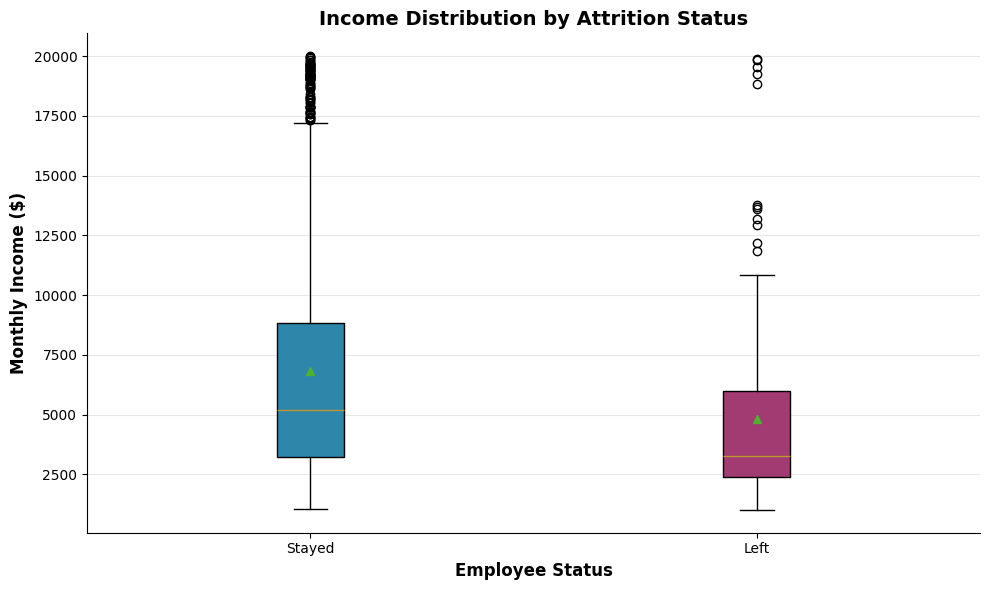

Median income (Stayed): $5205
Median income (Left): $3270


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data
stayed = df[df['Attrition'] == 'No']['MonthlyIncome']
left = df[df['Attrition'] == 'Yes']['MonthlyIncome']

# Create box plot
bp = ax.boxplot([stayed, left], 
                 labels=['Stayed', 'Left'],
                 patch_artist=True,
                 showmeans=True)

# Color the boxes
bp['boxes'][0].set_facecolor('#2E86AB')
bp['boxes'][1].set_facecolor('#A23B72')

ax.set_ylabel('Monthly Income ($)', fontsize=12, fontweight='bold')
ax.set_xlabel('Employee Status', fontsize=12, fontweight='bold')
ax.set_title('Income Distribution by Attrition Status', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Median income (Stayed): ${stayed.median():.0f}")
print(f"Median income (Left): ${left.median():.0f}")

## Bar Chart: Attrition Rate by Department

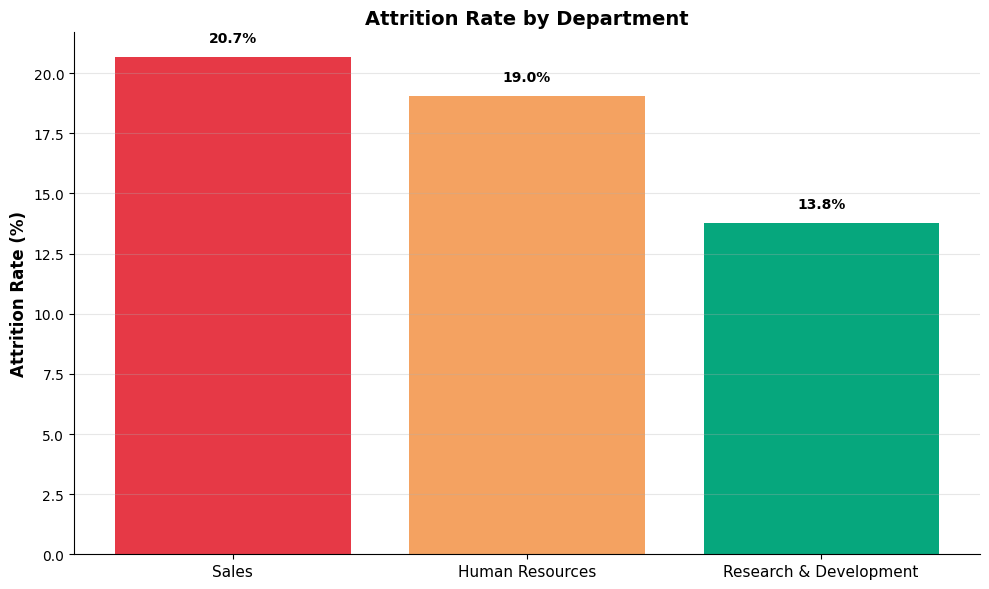

In [8]:
# Calculate attrition rates
dept_attrition = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(range(len(dept_attrition)), dept_attrition.values,
              color=['#E63946', '#F4A261', '#06A77D'])

ax.set_xticks(range(len(dept_attrition)))
ax.set_xticklabels(dept_attrition.index, fontsize=11)
ax.set_ylabel('Attrition Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Attrition Rate by Department', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, dept_attrition.values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary

## The Progression Journey

| Level | Lines of Code | Time | Use Case |
|-------|--------------|------|----------|
| **Basic** | 3 | 30 sec | Quick exploration |
| **Explanatory** | 20 | 5 min | Team presentations |
| **Exhibitive** | 60+ | 20 min | Publications |

## Key Principles

1. **Start Simple** - Basic plots for exploration
2. **Add Context** - Labels, titles, legends for communication
3. **Polish** - Professional styling for presentation
4. **Every Element Has Purpose** - Remove chart junk

## When to Use Each Level

### Basic
✅ Personal exploration  
✅ Quick checks  
❌ Sharing with others  

### Explanatory
✅ Team meetings  
✅ Documentation  
❌ Executive presentations  

### Exhibitive
✅ Executive presentations  
✅ Publications  
✅ Client deliverables  
❌ Quick iteration  

## Your Next Steps

1. Practice the progression with your own data
2. Build a template library
3. Always ask: who's my audience?

**Remember**: The best visualization clearly communicates your insight to your specific audience.